In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

# Load Datasets

In [2]:
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

# Data Cleaning

In [6]:
trades["Date"] = pd.to_datetime(
    trades["Timestamp IST"],
    format="%d-%m-%Y %H:%M"
).dt.date

sentiment["date"] = pd.to_datetime(sentiment["date"]).dt.date

print(trades.isnull().sum())
print(sentiment.isnull().sum())

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
Date                0
dtype: int64
timestamp         0
value             0
classification    0
date              0
dtype: int64


# Merging The Data

In [8]:
df = trades.merge(
    sentiment,
    left_on="Date",
    right_on="date",
    how="left"
)

df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,timestamp,value,classification,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02


# Basic Statistics

In [9]:
# Basic Statistics
print(df.describe())

print(df["classification"].value_counts())

       Execution Price   Size Tokens      Size USD  Start Position  \
count     53319.000000  5.331900e+04  5.331900e+04    5.331900e+04   
mean      27007.259468  1.246548e+04  1.341699e+04    8.437779e+03   
std       40085.031603  2.012052e+05  6.735278e+04    6.333108e+05   
min           0.000010  1.000000e-05  0.000000e+00   -1.433463e+07   
25%           4.875650  2.169750e-01  2.932500e+02   -4.946076e+02   
50%          98.536000  9.000000e+00  1.126510e+03    2.421750e+00   
75%       83072.500000  1.584050e+02  6.917245e+03    1.501610e+03   
max      108410.000000  1.582244e+07  3.921431e+06    3.050948e+07   

          Closed PnL      Order ID           Fee      Trade ID     Timestamp  \
count   53319.000000  5.331900e+04  53319.000000  5.331900e+04  5.331900e+04   
mean      118.570572  6.189290e+10      2.778454  5.644288e+14  1.734542e+12   
std      1560.428717  2.636057e+10     11.732133  3.264455e+14  1.294435e+10   
min   -117990.104100  4.064961e+09     -1.175712 

# Visualization 1
Fear vs Greed Distribution

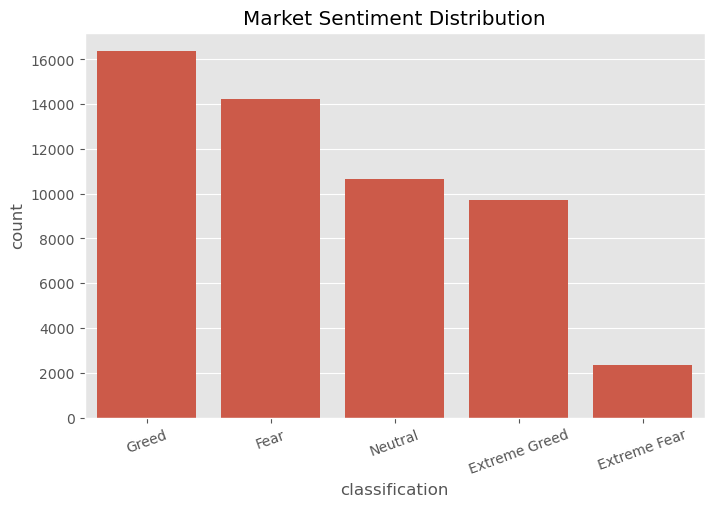

In [10]:
#Visualization 1
#Fear vs Greed Distribution
plt.figure(figsize=(8,5))

sns.countplot(
    x="classification",
    data=df,
    order=df["classification"].value_counts().index
)

plt.xticks(rotation=20)
plt.title("Market Sentiment Distribution")
plt.show()


# Visualization 2
 Average Profit By Sentiment

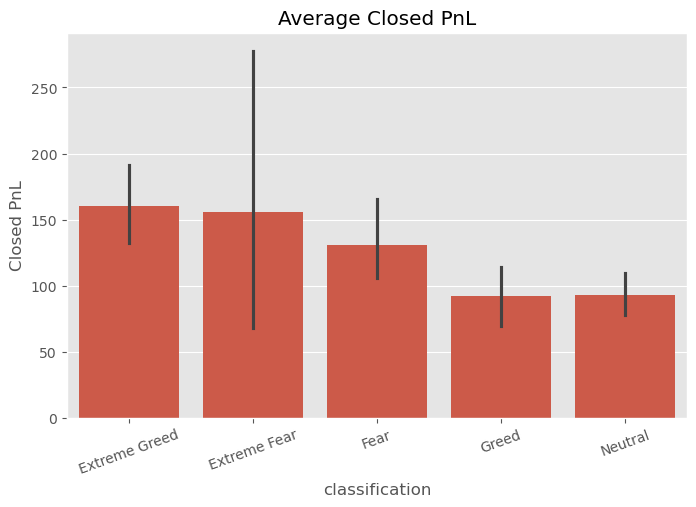

In [11]:
# Visualization 2
# Average Profit By Sentiment
plt.figure(figsize=(8,5))

sns.barplot(
    x="classification",
    y="Closed PnL",
    data=df,
    estimator=np.mean
)

plt.xticks(rotation=20)
plt.title("Average Closed PnL")
plt.show()

# Visualization 3
Profit Distribution

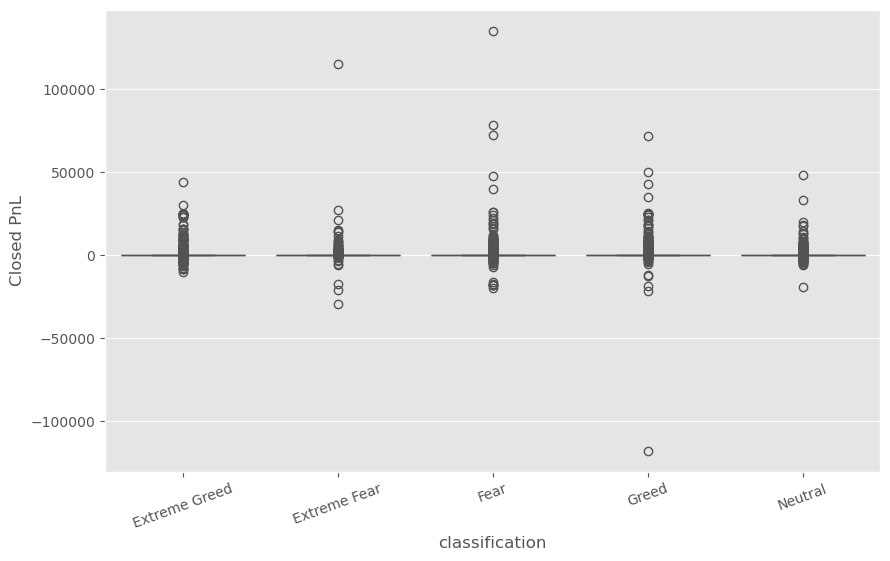

In [13]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x="classification",
    y="Closed PnL",
    data=df
)

plt.xticks(rotation=20)
plt.show()

# Visualization 4
Buy VS Sell

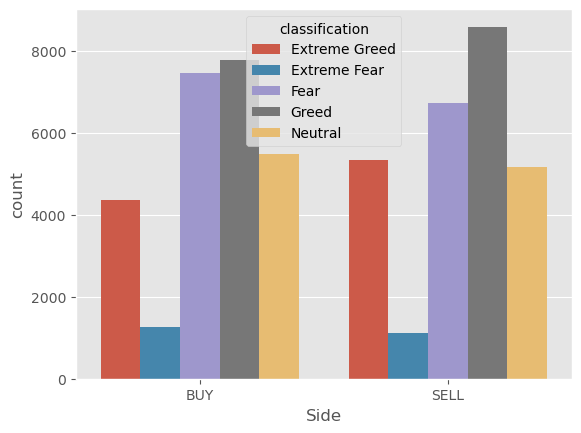

In [15]:
sns.countplot(
    x="Side",
    hue="classification",
    data=df
)

plt.show()

# Visualization 5
Trading Volume

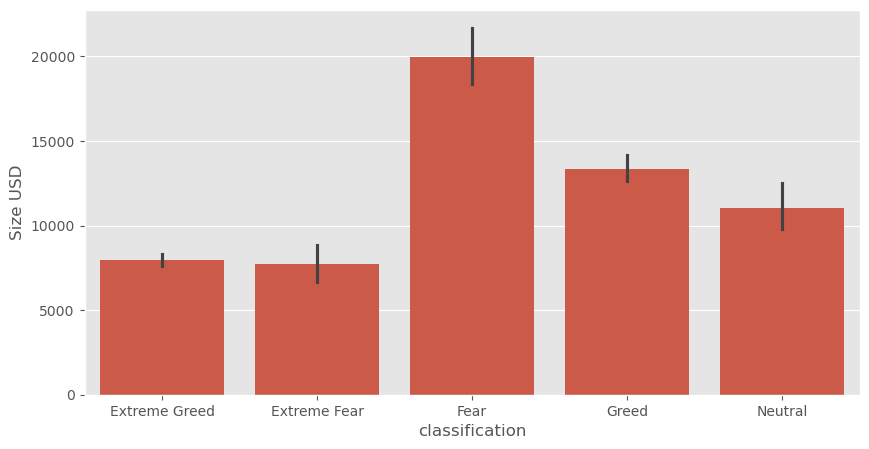

In [16]:
plt.figure(figsize=(10,5))

sns.barplot(
    x="classification",
    y="Size USD",
    data=df,
    estimator=np.mean
)

plt.show()

# Visualization 6
Fees

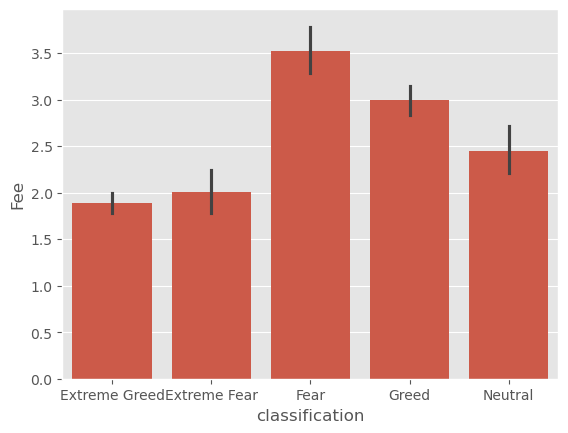

In [17]:
sns.barplot(
    x="classification",
    y="Fee",
    data=df,
    estimator=np.mean
)

plt.show()

# Top Coins

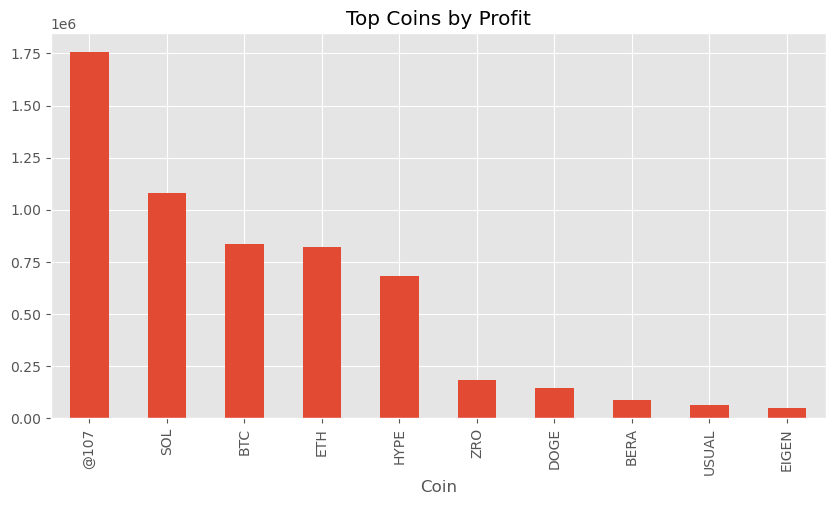

In [18]:
top = df.groupby("Coin")["Closed PnL"].sum()

top.sort_values(ascending=False).head(10).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top Coins by Profit")
plt.show()

# Correlation

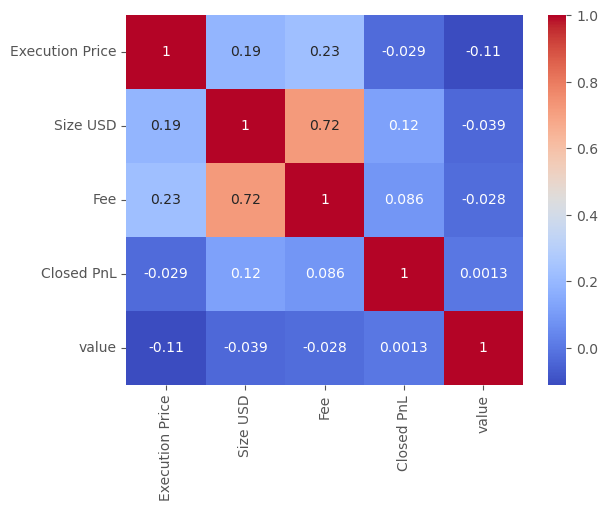

In [19]:
corr = df[[
    "Execution Price",
    "Size USD",
    "Fee",
    "Closed PnL",
    "value"
    
]].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.show()